<a href="https://colab.research.google.com/github/cyrusjimenez60/Regression-Fitting-BloodPressure/blob/main/Blood_Pressure_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Upload Dataset and Model Files

In [ ]:
# Upload blood-pressure-usa.csv and linear_model.py.

from google.colab import files
uploaded = files.upload()

Saving blood-pressure-usa.csv to blood-pressure-usa.csv
Saving linear_model.py to linear_model.py


## Import Libraries and Load Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from linear_model import LinearModel

# Load the US blood pressure dataset
df = pd.read_csv('blood-pressure-usa.csv')

# Average the three blood pressure readings
df['bp'] = df[['bp1', 'bp2', 'bp3']].mean(axis=1)

# Feature (x) and target (y)
x = df['age']
y = df['bp']

# Split dataset: 80% training, 20% testing
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Dataset loaded: {len(df)} individuals")
print(f"Training samples: {len(x_train)}")
print(f"Testing samples:  {len(x_test)}")

df.head()

Dataset loaded: 100 individuals
Training samples: 80
Testing samples:  20


,age,bp1,bp2,bp3,bp
0,46,122,129,122,124.333333
1,43,113,116,111,113.333333
2,29,102,107,105,104.666667
3,12,100,102,102,101.333333
4,9,112,138,94,114.666667


## Dataset Visualization

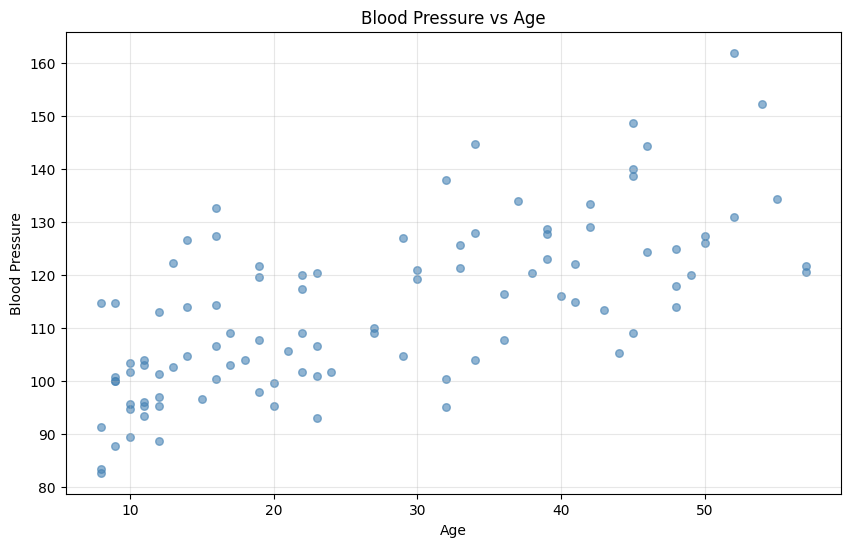

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(x, y, color='steelblue', alpha=0.6, s=30)

plt.xlabel('Age')
plt.ylabel('Blood Pressure')
plt.title('Blood Pressure vs Age')

plt.grid(True, alpha=0.3)
plt.show()

## Define a Polynomial Model Builder

In [ ]:
class PolynomialModel(LinearModel):
    """
    Extends LinearModel to support polynomial regression of any degree.
    Inherits model_name, fit(), rsquared, and print_model_info() from LinearModel.
    """

    def fit_poly(self, x, y, degree):
        """Transform x into polynomial features, then fit using LinearModel."""
        self.degree = degree
        self.poly = PolynomialFeatures(degree=degree, include_bias=False)
        x_poly = self.poly.fit_transform(x.values.reshape(-1, 1))

        # Fit via parent LinearModel (stores slope of first feature + intercept + R²)
        super().fit(x_poly, y)

        # Also store the full coefficient array for multi-feature prediction
        lr = LinearRegression().fit(x_poly, y)
        self.full_coef = lr.coef_
        return self

    def predict_range(self, x_vals):
        """Predict bp for a range of age values using all polynomial coefficients."""
        x_poly = self.poly.transform(x_vals.reshape(-1, 1))
        return x_poly @ self.full_coef + self.intercept

# Fit the three models
model_underfit = PolynomialModel(model_name="Underfit — Degree 1").fit_poly(x_train, y_train, degree=1)
model_goodfit = PolynomialModel(model_name="Good Fit — Degree 4").fit_poly(x_train, y_train, degree=4)
model_overfit = PolynomialModel(model_name="Overfit — Degree 20").fit_poly(x_train, y_train, degree=20)

print("All three models fitted successfully.")

All three models fitted successfully.


## R-Squared Scores

In [ ]:
from sklearn.metrics import r2_score

print("=" * 80)
print(f"{'Model':<25} {'Training R²':>15} {'Test R²':>15}")
print("=" * 80)

for model in [model_underfit, model_goodfit, model_overfit]:

    y_pred_test = model.predict_range(x_test.values)

    test_r2 = r2_score(y_test, y_pred_test)

    print(
        f"{model.model_name:<25}"
        f"{model.rsquared:>15.4f}"
        f"{test_r2:>15.4f}"
    )

print("=" * 80)
print()

print("Key Insight:")
print("  Underfit  → Low training and test R².")
print("  Good Fit  → Similar training and test R².")
print("  Overfit   → Training R² is much higher than test R².")

Model                         Training R²         Test R²
Underfit — Degree 1               0.4795         0.4232
Good Fit — Degree 4               0.4955         0.4327
Overfit — Degree 20               0.4588         0.3414

Key Insight:
  Underfit  → Low training and test R².
  Good Fit  → Similar training and test R².
  Overfit   → Training R² is much higher than test R².


## Separate Plots (One per Model)

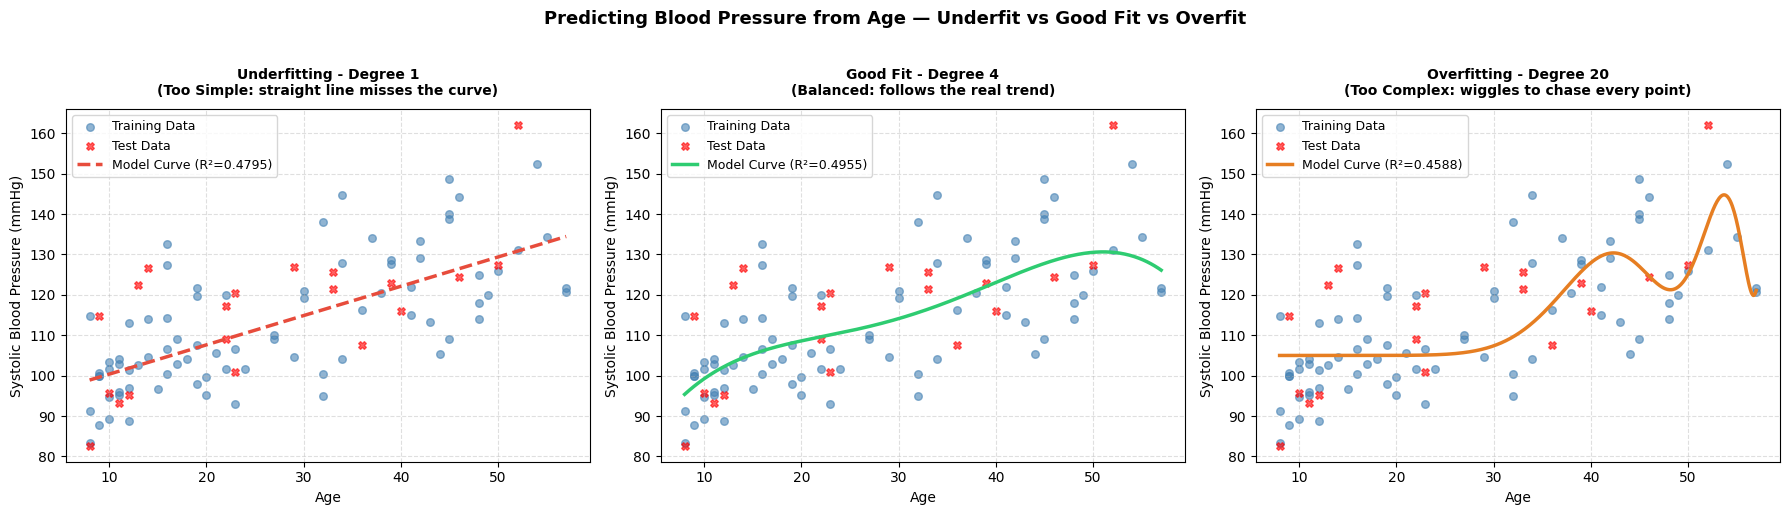

Saved: separate_plots.png


In [ ]:
# Generate a smooth range of age values
x_range = np.linspace(
    min(x_train.min(), x_test.min()),
    max(x_train.max(), x_test.max()),
    500
)

plot_configs = [
    (model_underfit, '#e74c3c', '--', 'Underfitting - Degree 1\n(Too Simple: straight line misses the curve)'),
    (model_goodfit,  '#2ecc71', '-',  'Good Fit - Degree 4\n(Balanced: follows the real trend)'),
    (model_overfit,  '#e67e22', '-',  'Overfitting - Degree 20\n(Too Complex: wiggles to chase every point)'),
]

# Create a figure with three side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall title
fig.suptitle(
    'Predicting Blood Pressure from Age — Underfit vs Good Fit vs Overfit',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, (model, color, linestyle, title) in zip(axes, plot_configs):
    y_curve = model.predict_range(x_range)

    ax.scatter(x_train, y_train, color='steelblue', alpha=0.6, s=30, label='Training Data')
    ax.scatter(x_test, y_test, color='red', alpha=0.6, s=30, marker='X', label='Test Data')
    ax.plot(
        x_range, y_curve,
        color=color, linewidth=2.5, linestyle=linestyle,
        label=f'Model Curve (R²={model.rsquared:.4f})'
    )
    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Age', fontsize=10)
    ax.set_ylabel('Systolic Blood Pressure (mmHg)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('separate_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: separate_plots.png")

## Combined Comparison Plot

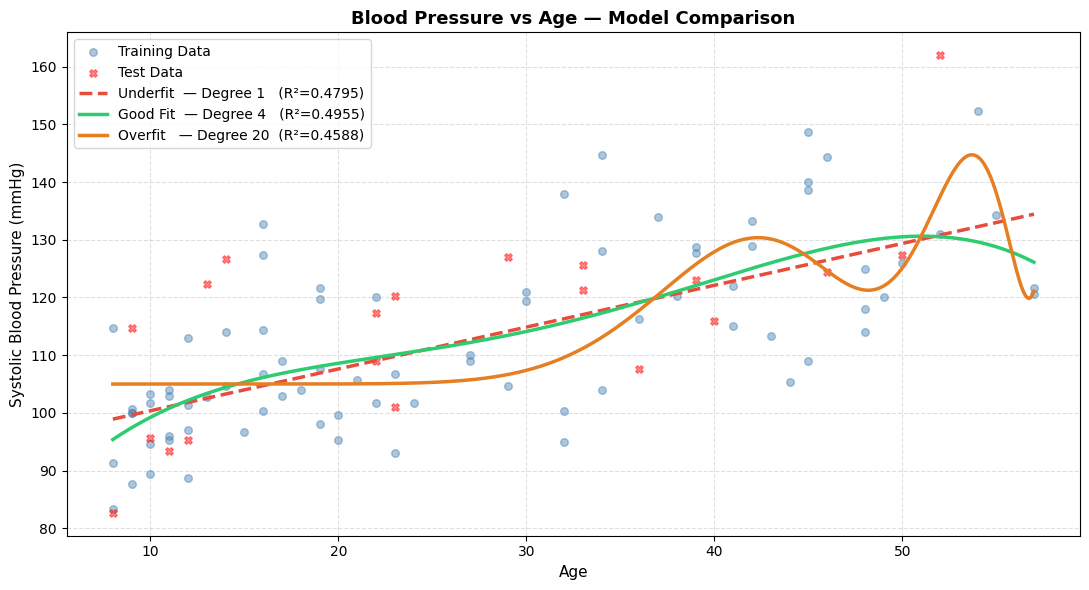

Saved: combined_plot.png


In [ ]:
plt.figure(figsize=(11, 6))

# Scatter: actual data points
plt.scatter(x_train, y_train, color='steelblue', alpha=0.45, s=30, label='Training Data', zorder=2)
plt.scatter(x_test, y_test, color='red', alpha=0.45, s=30, marker='X', label='Test Data', zorder=2)

# Each model curve
combined_configs = [
    (model_underfit, '#e74c3c', '--', f'Underfit  — Degree 1   (R²={model_underfit.rsquared:.4f})'),
    (model_goodfit,  '#2ecc71', '-',  f'Good Fit  — Degree 4   (R²={model_goodfit.rsquared:.4f})'),
    (model_overfit,  '#e67e22', '-',  f'Overfit   — Degree 20  (R²={model_overfit.rsquared:.4f})'),
]

for model, color, linestyle, label in combined_configs:
    y_curve = model.predict_range(x_range)
    plt.plot(x_range, y_curve, color=color, linewidth=2.5, linestyle=linestyle, label=label, zorder=3)

plt.title('Blood Pressure vs Age — Model Comparison', fontsize=13, fontweight='bold')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Systolic Blood Pressure (mmHg)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('combined_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: combined_plot.png")

## Summary of Model Information

In [ ]:
print("=" * 85)
print(f"{'Model':<25} {'Train R²':>10} {'Test R²':>10} {'Train MSE':>15} {'Test MSE':>15}")
print("=" * 85)

for model in [model_underfit, model_goodfit, model_overfit]:

    y_pred_train = model.predict_range(x_train.values)
    y_pred_test = model.predict_range(x_test.values)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)

    print(f"{model.model_name:<25} {train_r2:>10.4f} {test_r2:>10.4f} {train_mse:>15.4f} {test_mse:>15.4f}")

print("=" * 85)
print()

for model in [model_underfit, model_goodfit, model_overfit]:
    model.print_model_info()
    print(f'Polynomial Degree: {model.degree}')
    print('-' * 60)

Model                       Train R²    Test R²       Train MSE        Test MSE
Underfit — Degree 1           0.4795     0.4232        125.9756        161.1558
Good Fit — Degree 4           0.4955     0.4327        122.0806        158.5023
Overfit — Degree 20           0.4588     0.3414        130.9805        184.0303

LinearModel(Underfit — Degree 1):
Slope: 0.7250818184993348
Intercept: 93.1117512793138
R-squared: 0.47945443104923036
Polynomial Degree: 1
------------------------------------------------------------
LinearModel(Good Fit — Degree 4):
Slope: 5.418766981846327
Intercept: 66.36971662377181
R-squared: 0.4955489655610409
Polynomial Degree: 4
------------------------------------------------------------
LinearModel(Overfit — Degree 20):
Slope: 2.695357237741357e-44
Intercept: 104.99524361553972
R-squared: 0.4587736308352933
Polynomial Degree: 20
------------------------------------------------------------


In [ ]:
print()
print('Interpretation Guide:')
print('  Underfit  → High bias, low variance. Training and test performance are both relatively poor.')
print('  Good Fit  → Balanced bias and variance. Achieves strong generalization on unseen data.')
print('  Overfit   → Lower bias but higher variance. May fit training patterns that do not generalize.')
print('  R²        → Higher values indicate better explanatory power.')
print('  MSE       → Lower values indicate more accurate predictions.')


Interpretation Guide:
  Underfit  → High bias, low variance. Training and test performance are both relatively poor.
  Good Fit  → Balanced bias and variance. Achieves strong generalization on unseen data.
  Overfit   → Lower bias but higher variance. May fit training patterns that do not generalize.
  R²        → Higher values indicate better explanatory power.
  MSE       → Lower values indicate more accurate predictions.
